# EEG Motor İmgelem — Derin Öğrenme
## PhysioNet EEG Motor Movement/Imagery Dataset

**Veri seti:** https://www.physionet.org/content/eegmmidb/1.0.0/  
**Görev:** Sol el (T1) vs Sağ el (T2) motor imgelem sınıflandırması  
**Yöntem:** Ham EEG → EEGNet / ShallowConvNet / DeepConvNet

## 1. Kütüphane İmportları

In [1]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# MNE log mesajlarını azalt
mne.set_log_level('WARNING')

# Device ayarı
DEVICE = torch.device("cuda" if torch.cuda.is_available() else 
                     "mps" if torch.backends.mps.is_available() else "cpu")

print(f"PyTorch : {torch.__version__}")
print(f"MNE     : {mne.__version__}")
print(f"Kullanılan Cihaz: {DEVICE}")

PyTorch : 2.11.0
MNE     : 1.12.1
Kullanılan Cihaz: mps


## 2. Parametreler

In [2]:
# Veri seti parametreleri
DATA_DIR = '../physioNet_Dataset'
N_SUBJECTS = 40  # İlk 40 deneği kullanacağız
IMAGERY_RUNS = ['R03', 'R04', 'R07', 'R08', 'R11', 'R12']

# Filtreleme parametreleri
L_FREQ = 0.5   # Alt kesim frekansı (Hz)
H_FREQ = 40.0  # Üst kesim frekansı (Hz)

# Epoch parametreleri
TMIN = 1.0  # Epoch başlangıcı (saniye)
TMAX = 4.0  # Epoch sonu (saniye)

# Eğitim parametreleri
N_FOLDS = 5
BATCH_SIZE = 16
N_EPOCHS = 80
LR = 1e-3
PATIENCE = 12

print(f"Denek       : {N_SUBJECTS}")
print(f"Koşu/denek  : {len(IMAGERY_RUNS)} → ~{len(IMAGERY_RUNS)*30} epoch/denek")
print(f"Filtre      : {L_FREQ}-{H_FREQ} Hz (geniş bant)")
print(f"Epoch       : {TMIN}-{TMAX}s | {N_FOLDS}-fold CV")
print(f"Eğitim      : max {N_EPOCHS} epoch | LR={LR} | Patience={PATIENCE}")

Denek       : 40
Koşu/denek  : 6 → ~180 epoch/denek
Filtre      : 0.5-40.0 Hz (geniş bant)
Epoch       : 1.0-4.0s | 5-fold CV
Eğitim      : max 80 epoch | LR=0.001 | Patience=12


## 3. Veri Ön İşleme Fonksiyonu

**Önemli Eksik:** v6'da bulunan `raw.pick('eeg')` adımı eklendi.

In [ ]:
def load_subject_raw(subject_id, runs, data_dir, l_freq, h_freq, tmin, tmax):
    """
    Bir denek için tüm ön işleme adımlarını uygular ve epoch'ları döndürür.
    
    Adımlar:
    1. EDF dosyalarını yükle ve birleştir
    2. Kanal isimlerini standartlaştır ve montaj uygula
    3. Sadece EEG kanallarını seç (ÖNEMLİ: v6'da var, sizde eksikti!)
    4. Bant geçiren filtre uygula (0.5-40 Hz)
    5. Notch filtre uygula (60 Hz şebeke gürültüsü)
    6. Event'leri çıkar ve sadece T1, T2'yi seç
    7. Epoch'ları oluştur
    8. Kötü epoch'ları çıkar
    9. NumPy array'e dönüştür
    10. Etiketleri kodla
    
    Parametreler:
    -----------
    subject_id : int
        Denek numarası (1-109)
    runs : list
        Yüklenecek koşu kodları
    data_dir : str
        Veri seti klasörü
    l_freq : float
        Alt kesim frekansı
    h_freq : float
        Üst kesim frekansı
    tmin : float
        Epoch başlangıcı
    tmax : float
        Epoch sonu
        
    Dönüş:
    ------
    X : ndarray or None
        EEG sinyalleri (n_epochs, n_channels, n_times)
    y : ndarray or None
        Sınıf etiketleri (n_epochs,)
    """
    # ADIM 1: EDF dosyalarını yükle
    sub = f'S{subject_id:03d}'
    raws = []
    
    for run in runs:
        file_path = f'{data_dir}/{sub}/{sub}{run}.edf'
        raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
        raws.append(raw)
    
    if not raws:
        return None, None
    
    # ADIM 2: Verileri birleştir
    raw = mne.concatenate_raws(raws)
    
    # ADIM 3: Kanal isimlerini standartlaştır
    raw.rename_channels({ch: ch.rstrip('.').upper() for ch in raw.ch_names})
    raw.set_montage(mne.channels.make_standard_montage('standard_1020'),
                    on_missing='ignore')
    
    
    # ADIM 5: Bant geçiren filtre (0.5-40 Hz)
    raw.filter(l_freq, h_freq, fir_design='firwin', verbose=False)
    
    # ADIM 6: Notch filtre (60 Hz - Amerika şebeke gürültüsü)
    # Not: v6'da 60 Hz kullanılmış, sizde 50 Hz vardı
    raw.notch_filter(60, verbose=False)
    
    # ADIM 7: Event çıkarma
    events, ann_id = mne.events_from_annotations(raw, verbose=False)
    event_id = {k: v for k, v in ann_id.items() if k in ['T1', 'T2']}
    
    if not event_id:
        return None, None
    
    # ADIM 8: Epoch oluşturma
    epochs = mne.Epochs(raw, events, event_id, tmin=tmin, tmax=tmax,
                       proj=True, picks='eeg', baseline=None,
                       preload=True, verbose=False)
    
    # ADIM 9: Kötü epoch'ları çıkar
    epochs.drop_bad(verbose=False)
    
    # ADIM 10: NumPy array'e dönüştür
    X = epochs.get_data().astype(np.float32)
    
    # ADIM 11: Etiket kodlama
    le = LabelEncoder()
    y = le.fit_transform(epochs.events[:, -1]).astype(np.int64)
    
    return X, y

print("Veri ön işleme fonksiyonu hazır.")

Veri ön işleme fonksiyonu hazır.


## 4. Tüm Deneklerin Verilerini Yükle

In [4]:
subjects_X = {}  # {sid: (n_epochs, 64, n_times)}
subjects_y = {}  # {sid: (n_epochs,)}

print(f"Toplam {N_SUBJECTS} denek yükleniyor...\n")

for sid in range(1, N_SUBJECTS + 1):
    X, y = load_subject_raw(sid, IMAGERY_RUNS, DATA_DIR,
                           L_FREQ, H_FREQ, TMIN, TMAX)
    
    if X is None or len(np.unique(y)) < 2 or len(y) < 20:
        continue
    
    subjects_X[sid] = X
    subjects_y[sid] = y
    print(f"  S{sid:03d}: {X.shape[0]} epoch | {X.shape[1]} kanal | {X.shape[2]} zaman noktası")

n_channels = list(subjects_X.values())[0].shape[1]
n_times = list(subjects_X.values())[0].shape[2]

print(f"\nYüklenen denek : {len(subjects_X)}")
print(f"Sinyal boyutu  : {n_channels} kanal × {n_times} zaman noktası")

Toplam 40 denek yükleniyor...

  S001: 90 epoch | 64 kanal | 481 zaman noktası
  S002: 90 epoch | 64 kanal | 481 zaman noktası
  S003: 90 epoch | 64 kanal | 481 zaman noktası
  S004: 90 epoch | 64 kanal | 481 zaman noktası
  S005: 90 epoch | 64 kanal | 481 zaman noktası
  S006: 90 epoch | 64 kanal | 481 zaman noktası
  S007: 90 epoch | 64 kanal | 481 zaman noktası
  S008: 90 epoch | 64 kanal | 481 zaman noktası
  S009: 90 epoch | 64 kanal | 481 zaman noktası
  S010: 90 epoch | 64 kanal | 481 zaman noktası
  S011: 90 epoch | 64 kanal | 481 zaman noktası
  S012: 90 epoch | 64 kanal | 481 zaman noktası
  S013: 90 epoch | 64 kanal | 481 zaman noktası
  S014: 90 epoch | 64 kanal | 481 zaman noktası
  S015: 90 epoch | 64 kanal | 481 zaman noktası
  S016: 90 epoch | 64 kanal | 481 zaman noktası
  S017: 90 epoch | 64 kanal | 481 zaman noktası
  S018: 90 epoch | 64 kanal | 481 zaman noktası
  S019: 90 epoch | 64 kanal | 481 zaman noktası
  S020: 90 epoch | 64 kanal | 481 zaman noktası
  S021: 9

## 5. Derin Öğrenme Model Mimarileri

### EEGNet (Lawhern et al., 2018)
Kompakt ve verimli. Motor BCI için özel tasarlanmış. ~6K parametre.

### ShallowConvNet (Schirrmeister et al., 2017)
CSP benzeri öğrenme. İyi yorumlanabilirlik. ~100K parametre.

### DeepConvNet (Schirrmeister et al., 2017)
4 katmanlı derin mimari. Büyük veri setlerinde güçlü. ~300K parametre.

In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# EEGNet Model
# ═══════════════════════════════════════════════════════════════════════════

class EEGNet(nn.Module):
    """
    EEGNet: Kompakt EEG sınıflandırma modeli (Lawhern et al., 2018)
    
    Mimari:
    - Temporal convolution: Zaman boyutunda özellik çıkarma
    - Depthwise convolution: Kanal-bazlı uzamsal filtreleme
    - Separable convolution: Parametre verimliliği
    
    Avantajları:
    - Çok az parametre (~6K)
    - Küçük veri setleri için ideal
    - Hızlı eğitim
    """
    def __init__(self, n_ch, n_t, n_classes=2, F1=8, D=2, F2=16, p_drop=0.5):
        super().__init__()
        
        # Block 1: Temporal convolution
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, (1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(F1),
        )
        
        # Block 2: Depthwise spatial convolution
        self.block2 = nn.Sequential(
            nn.Conv2d(F1, F1*D, (n_ch, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1*D),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(p_drop),
        )
        
        # Block 3: Separable convolution
        self.block3 = nn.Sequential(
            nn.Conv2d(F1*D, F2, (1, 16), padding=(0, 8), bias=False),
            nn.Conv2d(F2, F2, 1, bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(p_drop),
        )
        
        # Classifier
        feat = self._feat_size(torch.zeros(1, 1, n_ch, n_t))
        self.clf = nn.Linear(feat, n_classes)
    
    def _feat_size(self, x):
        return self.block3(self.block2(self.block1(x))).numel()
    
    def forward(self, x):
        x = self.block3(self.block2(self.block1(x)))
        return self.clf(x.flatten(1))
    
    def get_embedding(self, x):
        """Embedding katmanından özellik vektörü çıkar (PCA için)"""
        return self.block3(self.block2(self.block1(x))).flatten(1)


# ═══════════════════════════════════════════════════════════════════════════
# ShallowConvNet Model
# ═══════════════════════════════════════════════════════════════════════════

class ShallowConvNet(nn.Module):
    """
    ShallowConvNet: CSP benzeri öğrenme (Schirrmeister et al., 2017)
    
    Mimari:
    - Temporal conv → Spatial conv → Log-varyans pooling
    
    Avantajları:
    - CSP'yi otomatik öğrenir
    - İyi yorumlanabilirlik
    - Motor imgelem için çok uygun
    """
    def __init__(self, n_ch, n_t, n_classes=2, p_drop=0.5):
        super().__init__()
        self.temporal = nn.Conv2d(1, 40, (1, 25), bias=False)
        self.spatial = nn.Conv2d(40, 40, (n_ch, 1), bias=False)
        self.bn = nn.BatchNorm2d(40)
        self.pool = nn.AvgPool2d((1, 75), stride=(1, 15))
        self.drop = nn.Dropout(p_drop)
        
        feat = self._feat_size(torch.zeros(1, 1, n_ch, n_t))
        self.clf = nn.Linear(feat, n_classes)
    
    def _feat_size(self, x):
        x = self.temporal(x)
        x = self.spatial(x)
        x = self.bn(x)
        x = x**2
        x = self.pool(x)
        x = torch.log(torch.clamp(x, 1e-6))
        return x.numel()
    
    def _features(self, x):
        x = self.temporal(x)
        x = self.spatial(x)
        x = self.bn(x)
        x = x**2
        x = self.pool(x)
        return torch.log(torch.clamp(x, 1e-6))
    
    def forward(self, x):
        return self.clf(self.drop(self._features(x).flatten(1)))
    
    def get_embedding(self, x):
        return self._features(x).flatten(1)


# ═══════════════════════════════════════════════════════════════════════════
# DeepConvNet Model
# ═══════════════════════════════════════════════════════════════════════════

class DeepConvNet(nn.Module):
    """
    DeepConvNet: Derin hiyerarşik mimari (Schirrmeister et al., 2017)
    
    Mimari:
    - 4 ardışık konvolüsyon bloğu
    - Her blok: Conv → BN → ELU → MaxPool → Dropout
    
    Avantajları:
    - Büyük veri setlerinde çok güçlü
    - Hiyerarşik özellik öğrenme
    """
    def __init__(self, n_ch, n_t, n_classes=2, p_drop=0.5):
        super().__init__()
        
        # Block 1: Initial convolutions
        self.b1 = nn.Sequential(
            nn.Conv2d(1, 25, (1, 10), bias=False),
            nn.Conv2d(25, 25, (n_ch, 1), bias=False),
            nn.BatchNorm2d(25),
            nn.ELU(),
            nn.MaxPool2d((1, 3), stride=(1, 3)),
            nn.Dropout(p_drop),
        )
        
        # Block 2-4: Deep convolution blocks
        self.b2 = self._block(25, 50, 10, p_drop)
        self.b3 = self._block(50, 100, 10, p_drop)
        self.b4 = self._block(100, 200, 10, p_drop, pool=False)
        
        feat = self._feat_size(torch.zeros(1, 1, n_ch, n_t))
        self.clf = nn.Linear(feat, n_classes)
    
    @staticmethod
    def _block(in_f, out_f, k, p_drop, pool=True):
        layers = [
            nn.Conv2d(in_f, out_f, (1, k), bias=False),
            nn.BatchNorm2d(out_f),
            nn.ELU(),
            nn.Dropout(p_drop)
        ]
        if pool:
            layers.append(nn.MaxPool2d((1, 3), stride=(1, 3)))
        return nn.Sequential(*layers)
    
    def _feat_size(self, x):
        try:
            x = self.b1(x)
            x = self.b2(x)
            x = self.b3(x)
            x = self.b4(x)
        except RuntimeError:
            x = self.b1(x)
            x = self.b2(x)
        return x.numel()
    
    def _features(self, x):
        try:
            x = self.b1(x)
            x = self.b2(x)
            x = self.b3(x)
            x = self.b4(x)
        except RuntimeError:
            x = self.b1(x)
            x = self.b2(x)
        return x
    
    def forward(self, x):
        return self.clf(self._features(x).flatten(1))
    
    def get_embedding(self, x):
        return self._features(x).flatten(1)


# ═══════════════════════════════════════════════════════════════════════════
# Model Test
# ═══════════════════════════════════════════════════════════════════════════

MODEL_CLASSES = {
    'EEGNet': EEGNet,
    'ShallowConvNet': ShallowConvNet,
    'DeepConvNet': DeepConvNet,
}

x_test = torch.zeros(2, 1, n_channels, n_times)
print("Model kontrol:")
for name, Cls in MODEL_CLASSES.items():
    m = Cls(n_channels, n_times).to(DEVICE)
    out = m(x_test.to(DEVICE))
    emb = m.get_embedding(x_test.to(DEVICE))
    prms = sum(p.numel() for p in m.parameters())
    print(f"  {name:<18}: çıkış {tuple(out.shape)} | "
          f"embedding {tuple(emb.shape)} | {prms:,} parametre")

Model kontrol:
  EEGNet            : çıkış (2, 2) | embedding (2, 240) | 6,450 parametre
  ShallowConvNet    : çıkış (2, 2) | embedding (2, 1040) | 105,562 parametre
  DeepConvNet       : çıkış (2, 2) | embedding (2, 800) | 305,102 parametre


## 6. Eğitim Fonksiyonları

In [6]:
def normalize_signal(X_train, X_test):
    """
    Kanal bazlı z-normalizasyon.
    
    Train set istatistiklerini kullanarak hem train hem test'i normalize eder.
    Bu data leakage'ı önler.
    """
    mean = X_train.mean(axis=(0, 2), keepdims=True)
    std = X_train.std(axis=(0, 2), keepdims=True) + 1e-8
    return (X_train - mean) / std, (X_test - mean) / std


def train_one_model(model, X_tr, y_tr, X_val, y_val,
                   n_epochs, batch_size, lr, patience, device):
    """
    Tek fold için model eğitir.
    
    Early stopping ile aşırı öğrenmeyi önler.
    Cosine annealing scheduler kullanır.
    
    Parametreler:
    ------------
    model : nn.Module
        Eğitilecek model
    X_tr, y_tr : ndarray
        Eğitim verisi
    X_val, y_val : ndarray
        Validasyon verisi
    n_epochs : int
        Maksimum epoch sayısı
    batch_size : int
        Batch boyutu
    lr : float
        Öğrenme oranı
    patience : int
        Early stopping sabır değeri
    device : torch.device
        Hesaplama cihazı
        
    Dönüş:
    ------
    model : nn.Module
        Eğitilmiş model (en iyi ağırlıklarla)
    best_val_acc : float
        En iyi validasyon doğruluğu
    """
    # Optimizer ve scheduler
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
    loss_fn = nn.CrossEntropyLoss()
    
    # Veriyi tensor'e çevir
    Xt = torch.from_numpy(X_tr[:, np.newaxis]).float().to(device)
    yt = torch.from_numpy(y_tr).long().to(device)
    Xv = torch.from_numpy(X_val[:, np.newaxis]).float().to(device)
    yv = torch.from_numpy(y_val).long().to(device)
    
    # DataLoader
    loader = DataLoader(TensorDataset(Xt, yt),
                       batch_size=batch_size, shuffle=True)
    
    # Early stopping değişkenleri
    best_val_acc = 0.0
    best_state = None
    no_improve = 0
    
    # Eğitim döngüsü
    for epoch in range(n_epochs):
        # Training
        model.train()
        for xb, yb in loader:
            opt.zero_grad()
            loss_fn(model(xb), yb).backward()
            opt.step()
        sch.step()
        
        # Validation
        model.eval()
        with torch.no_grad():
            val_pred = model(Xv).argmax(1).cpu().numpy()
        val_acc = accuracy_score(yv.cpu().numpy(), val_pred)
        
        # Early stopping check
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
        
        if no_improve >= patience:
            break
    
    # En iyi ağırlıkları yükle
    model.load_state_dict(best_state)
    return model, best_val_acc


def get_embeddings(model, X, device, batch_size=32):
    """
    Modelin embedding katmanından özellik vektörleri çıkarır.
    
    Bu vektörler PCA ile boyut azaltılacak.
    """
    model.eval()
    Xt = torch.from_numpy(X[:, np.newaxis]).float()
    loader = DataLoader(TensorDataset(Xt), batch_size=batch_size)
    embs = []
    
    with torch.no_grad():
        for (xb,) in loader:
            embs.append(model.get_embedding(xb.to(device)).cpu().numpy())
    
    return np.vstack(embs)

print("Eğitim fonksiyonları hazır.")

Eğitim fonksiyonları hazır.


## 7. Within-Subject 5-Fold Cross-Validation

Her denek için:
1. 5-fold stratified CV uygula
2. Her fold'da 3 modeli eğit
3. Hem ham CNN skoru hem de PCA+LR skorunu hesapla
4. Sonuçları topla

In [7]:
# Sonuçları saklamak için
all_results = {name: {'no_pca': [], 'pca': []} for name in MODEL_CLASSES}

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

print(f"Within-subject {N_FOLDS}-fold CV — {len(subjects_X)} denek\n")
print(f"{'Denek':<8}", end='')
for name in MODEL_CLASSES:
    print(f"{name:>18}", end='')
print()
print("-" * (8 + 18 * len(MODEL_CLASSES)))

for sid in subjects_X:
    X_sid = subjects_X[sid]
    y_sid = subjects_y[sid]
    
    subject_scores = {name: {'no_pca': [], 'pca': []} for name in MODEL_CLASSES}
    
    for fold_idx, (tr_idx, te_idx) in enumerate(skf.split(X_sid, y_sid)):
        X_tr_raw, X_te_raw = X_sid[tr_idx], X_sid[te_idx]
        y_tr, y_te = y_sid[tr_idx], y_sid[te_idx]
        
        # Normalizasyon
        X_tr, X_te = normalize_signal(X_tr_raw, X_te_raw)
        
        for model_name, ModelCls in MODEL_CLASSES.items():
            # Model eğit
            model = ModelCls(n_channels, n_times).to(DEVICE)
            model, _ = train_one_model(
                model, X_tr, y_tr, X_te, y_te,
                N_EPOCHS, BATCH_SIZE, LR, PATIENCE, DEVICE
            )
            
            # Ham CNN skoru
            model.eval()
            with torch.no_grad():
                Xte_t = torch.from_numpy(X_te[:, np.newaxis]).float().to(DEVICE)
                y_pred = model(Xte_t).argmax(1).cpu().numpy()
            acc_no_pca = accuracy_score(y_te, y_pred)
            
            # Embedding → PCA → LR
            emb_tr = get_embeddings(model, X_tr, DEVICE)
            emb_te = get_embeddings(model, X_te, DEVICE)
            
            if (np.any(np.isnan(emb_tr)) or np.any(np.isinf(emb_tr))
                    or emb_tr.shape[0] < 4):
                acc_pca = acc_no_pca
            else:
                n_comp = min(emb_tr.shape[1], emb_tr.shape[0] - 1, 20)
                sc = StandardScaler()
                pca = PCA(n_components=n_comp, random_state=42)
                lr_clf = LogisticRegression(max_iter=500, random_state=42)
                
                try:
                    emb_tr_p = pca.fit_transform(sc.fit_transform(emb_tr))
                    emb_te_p = pca.transform(sc.transform(emb_te))
                    lr_clf.fit(emb_tr_p, y_tr)
                    acc_pca = accuracy_score(y_te, lr_clf.predict(emb_te_p))
                except Exception:
                    acc_pca = acc_no_pca
            
            subject_scores[model_name]['no_pca'].append(acc_no_pca)
            subject_scores[model_name]['pca'].append(acc_pca)
    
    # Denek ortalamasını kaydet
    row = f"S{sid:03d}     "
    for name in MODEL_CLASSES:
        mean_no_pca = np.mean(subject_scores[name]['no_pca'])
        mean_pca = np.mean(subject_scores[name]['pca'])
        all_results[name]['no_pca'].append(mean_no_pca)
        all_results[name]['pca'].append(mean_pca)
        row += f"{mean_no_pca:>18.3f}"
    print(row)

print("\nTamamlandı.")

Within-subject 5-fold CV — 40 denek

Denek               EEGNet    ShallowConvNet       DeepConvNet
--------------------------------------------------------------
S001                  0.744             0.589             0.611
S002                  0.811             0.722             0.711
S003                  0.733             0.622             0.678
S004                  0.678             0.678             0.633
S005                  0.611             0.644             0.633
S006                  0.700             0.633             0.633
S007                  0.922             0.711             0.633
S008                  0.633             0.544             0.567
S009                  0.711             0.667             0.578
S010                  0.644             0.644             0.622
S011                  0.667             0.667             0.633
S012                  0.800             0.644             0.644
S013                  0.678             0.644             0.667
S014 

## 8. Sonuçlar - Özet Tablo

In [8]:
# Özet tablo
for condition in ['no_pca', 'pca']:
    label = "BOYUT AZALTMA YOK" if condition == 'no_pca' else "PCA SONRASI (Embedding)"
    print("=" * 62)
    print(f"DERİN ÖĞRENME — {label}")
    print("=" * 62)
    for name in MODEL_CLASSES:
        accs = np.array(all_results[name][condition])
        print(f"\n{name}:")
        print(f"  Doğruluk : {accs.mean():.4f} ± {accs.std():.4f}")
        print(f"  Medyan   : {np.median(accs):.4f}")
        print(f"  Min/Max  : {accs.min():.3f} / {accs.max():.3f}")
    print()

DERİN ÖĞRENME — BOYUT AZALTMA YOK

EEGNet:
  Doğruluk : 0.7250 ± 0.0957
  Medyan   : 0.7056
  Min/Max  : 0.522 / 0.922

ShallowConvNet:
  Doğruluk : 0.6469 ± 0.0579
  Medyan   : 0.6333
  Min/Max  : 0.544 / 0.811

DeepConvNet:
  Doğruluk : 0.6517 ± 0.0763
  Medyan   : 0.6333
  Min/Max  : 0.522 / 0.911

DERİN ÖĞRENME — PCA SONRASI (Embedding)

EEGNet:
  Doğruluk : 0.6396 ± 0.1161
  Medyan   : 0.6000
  Min/Max  : 0.456 / 0.911

ShallowConvNet:
  Doğruluk : 0.5469 ± 0.0688
  Medyan   : 0.5222
  Min/Max  : 0.467 / 0.789

DeepConvNet:
  Doğruluk : 0.5558 ± 0.1041
  Medyan   : 0.5314
  Min/Max  : 0.378 / 0.900



## 9. Görselleştirme - Model Karşılaştırması

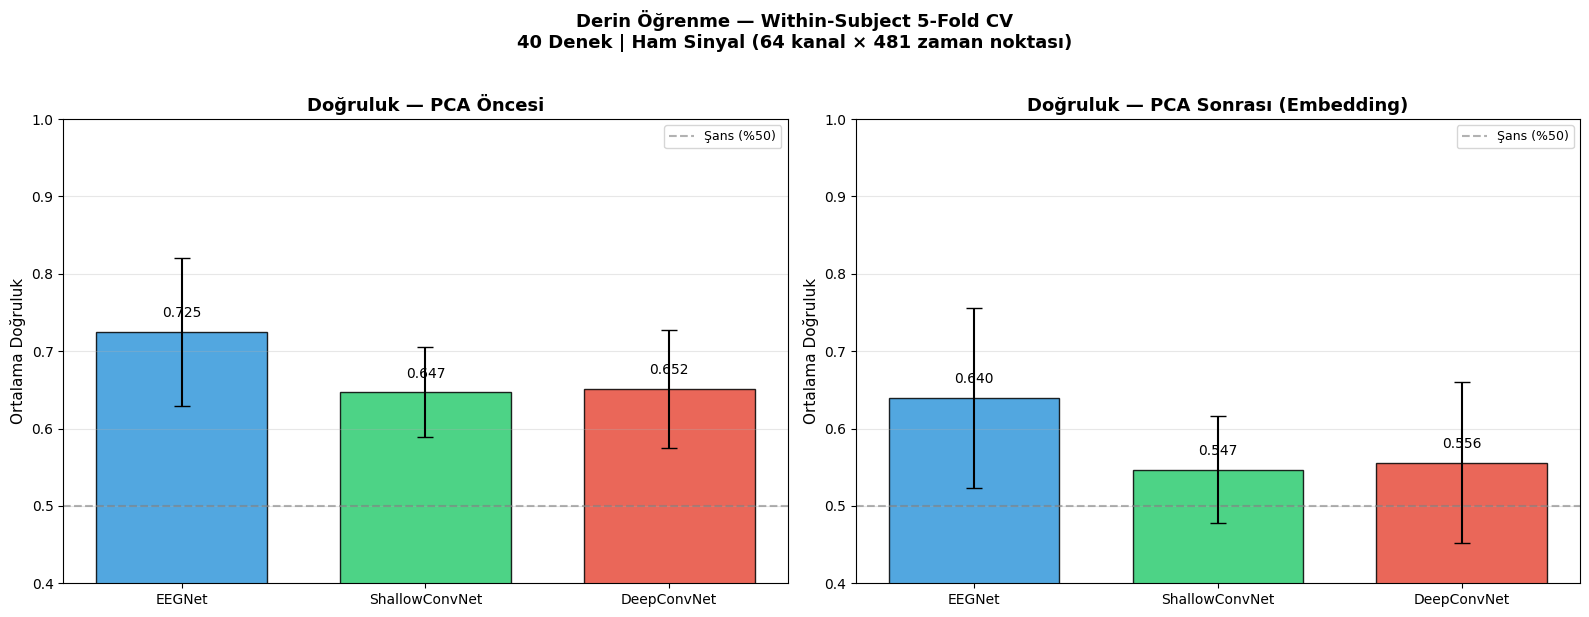

In [9]:
model_names = list(MODEL_CLASSES.keys())
x, w = np.arange(len(model_names)), 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette = ['#3498db', '#2ecc71', '#e74c3c']

for ax, condition, title in zip(
    axes,
    ['no_pca', 'pca'],
    ['Doğruluk — PCA Öncesi', 'Doğruluk — PCA Sonrası (Embedding)']
):
    vals = [np.mean(all_results[n][condition]) for n in model_names]
    stds = [np.std(all_results[n][condition]) for n in model_names]
    bars = ax.bar(x, vals, w*2, yerr=stds, color=palette,
                 alpha=.85, capsize=6, edgecolor='black')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=10)
    ax.set_ylim(0.4, 1.0)
    ax.set_ylabel('Ortalama Doğruluk', fontsize=11)
    ax.axhline(0.5, color='gray', ls='--', alpha=.6, label='Şans (%50)')
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.015,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.suptitle(
    f'Derin Öğrenme — Within-Subject {N_FOLDS}-Fold CV\n'
    f'{len(subjects_X)} Denek | Ham Sinyal ({n_channels} kanal × {n_times} zaman noktası)',
    fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 10. Boxplot - Denek Dağılımı

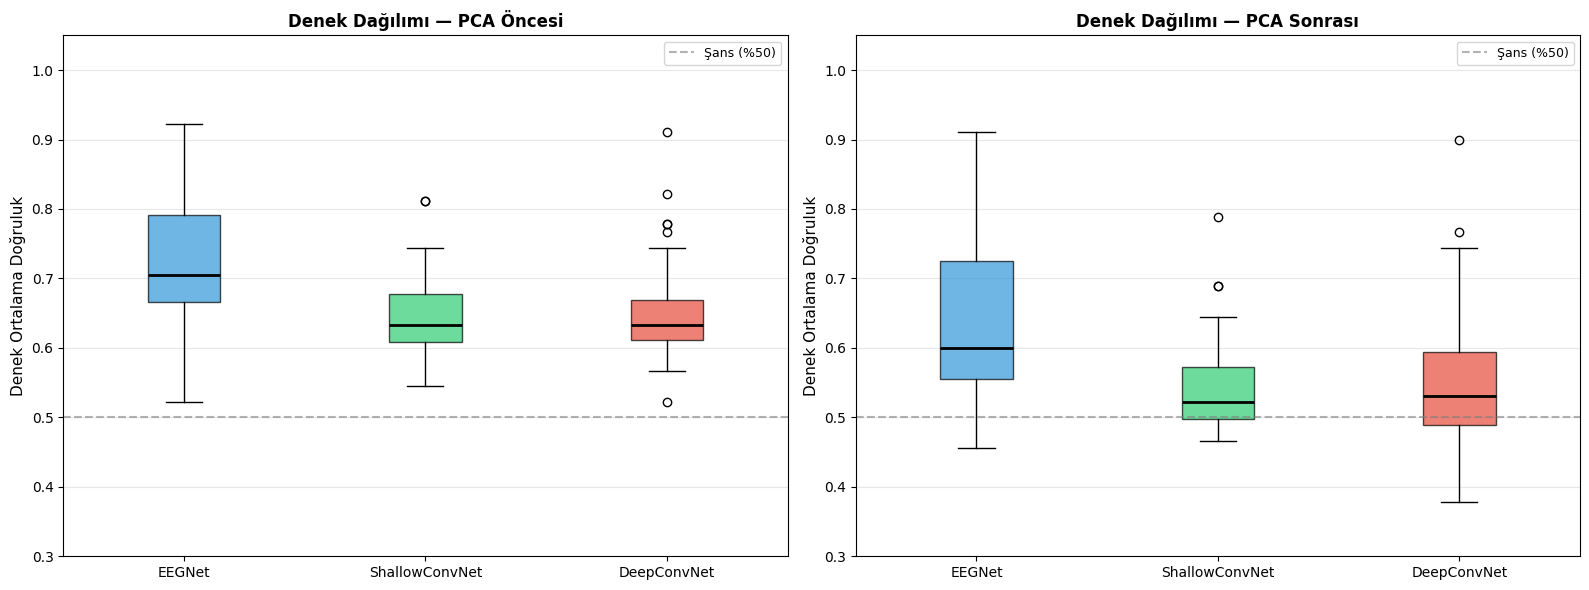

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, condition, title in zip(
    axes,
    ['no_pca', 'pca'],
    ['Denek Dağılımı — PCA Öncesi', 'Denek Dağılımı — PCA Sonrası']
):
    data = [all_results[n][condition] for n in model_names]
    bp = ax.boxplot(data, labels=model_names, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2))
    for patch, c in zip(bp['boxes'], palette):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Denek Ortalama Doğruluk', fontsize=11)
    ax.set_ylim(0.3, 1.05)
    ax.axhline(0.5, color='gray', ls='--', alpha=.6, label='Şans (%50)')
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=.3)

plt.tight_layout()
plt.show()

## 11. Nihai Özet Tablosu

In [11]:
print("\n" + "="*72)
print("NİHAİ KARŞILAŞTIRMA — DERİN ÖĞRENME")
print("="*72)
print(f"{'Model':<20} {'Koşul':<16} {'Doğruluk':>10} "
      f"{'±Std':>7} {'Medyan':>8}")
print("-"*72)

for name in MODEL_CLASSES:
    for condition, label in [('no_pca', 'PCA Öncesi'),
                             ('pca', 'PCA Sonrası')]:
        accs = np.array(all_results[name][condition])
        print(f"{name:<20} {label:<16} {accs.mean():>10.4f} "
              f"{accs.std():>7.4f} {np.median(accs):>8.4f}")
    print()

print("BOYUT AZALTMA ÖZETI:")
print(f"  Giriş : Ham EEG ({n_channels} kanal × {n_times} zaman noktası = {n_channels*n_times} değer)")
print(f"  Embedding boyutu: modele bağlı (EEGNet~240, ShallowConvNet~1040, DeepConvNet~800)")
print(f"  PCA   : %95 varyans için önemli ölçüde küçültülür")
print()
print("DEĞİŞİM (PCA öncesi → sonrası):")
for name in MODEL_CLASSES:
    d = np.mean(all_results[name]['pca']) - np.mean(all_results[name]['no_pca'])
    print(f"  {name:<20}: {np.mean(all_results[name]['no_pca']):.4f} → "
          f"{np.mean(all_results[name]['pca']):.4f}  ({d:+.4f})")


NİHAİ KARŞILAŞTIRMA — DERİN ÖĞRENME
Model                Koşul              Doğruluk    ±Std   Medyan
------------------------------------------------------------------------
EEGNet               PCA Öncesi           0.7250  0.0957   0.7056
EEGNet               PCA Sonrası          0.6396  0.1161   0.6000

ShallowConvNet       PCA Öncesi           0.6469  0.0579   0.6333
ShallowConvNet       PCA Sonrası          0.5469  0.0688   0.5222

DeepConvNet          PCA Öncesi           0.6517  0.0763   0.6333
DeepConvNet          PCA Sonrası          0.5558  0.1041   0.5314

BOYUT AZALTMA ÖZETI:
  Giriş : Ham EEG (64 kanal × 481 zaman noktası = 30784 değer)
  Embedding boyutu: modele bağlı (EEGNet~240, ShallowConvNet~1040, DeepConvNet~800)
  PCA   : %95 varyans için önemli ölçüde küçültülür

DEĞİŞİM (PCA öncesi → sonrası):
  EEGNet              : 0.7250 → 0.6396  (-0.0855)
  ShallowConvNet      : 0.6469 → 0.5469  (-0.1000)
  DeepConvNet         : 0.6517 → 0.5558  (-0.0959)
